<a href="https://colab.research.google.com/github/tnc1/ai-ml/blob/main/day10_task5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
  TASK 5 — HANDWRITTEN STUDENT ID RECOGNIZER
    (Computer Vision + CNN)
    The university wants AI to recognize handwritten student ID digits from uploaded images.

  Tasks
    1. Load MNIST dataset.
    2. Normalize images.
    3. Build a CNN model.
    4. Train the model.
    5. Predict handwritten digit from test dataset.
    6. Upload an external handwritten image.
    7. Preprocess image:
      ○ grayscale
      ○ resize
      ○ normalize
    8. Predict uploaded digit.
"""

'\n  TASK 5 — HANDWRITTEN STUDENT ID RECOGNIZER\n    (Computer Vision + CNN)\n    The university wants AI to recognize handwritten student ID digits from uploaded images.\n\n  Tasks\n    1. Load MNIST dataset.\n    2. Normalize images.\n    3. Build a CNN model.\n    4. Train the model.\n    5. Predict handwritten digit from test dataset.\n    6. Upload an external handwritten image.\n    7. Preprocess image:\n      ○ grayscale\n      ○ resize\n      ○ normalize\n    8. Predict uploaded digit.\n'

In [ ]:
# IMPORT LIBRARIES
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
mnist = tf.keras.datasets.mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

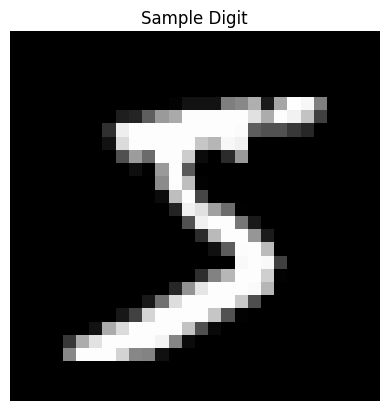

In [ ]:
plt.imshow(X_train[0], cmap='gray')

plt.title("Sample Digit")

plt.axis("off")

plt.show()

In [ ]:
# NORMALIZE IMAGES

X_train = X_train / 255.0

X_test = X_test / 255.0

In [ ]:
#  NEURAL NETWORK CODE
model = tf.keras.models.Sequential()

# ADD LAYERS CODE
model.add(
    tf.keras.layers.Flatten(input_shape=(28,28))
)

model.add(
    tf.keras.layers.Dense(
        128,
        activation='relu'
    )
)

model.add(
    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9267 - loss: 0.2584


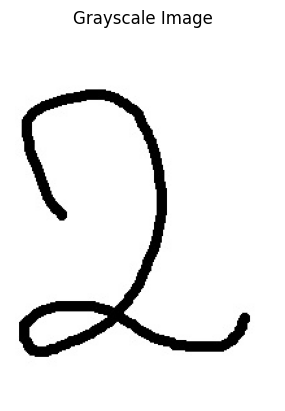

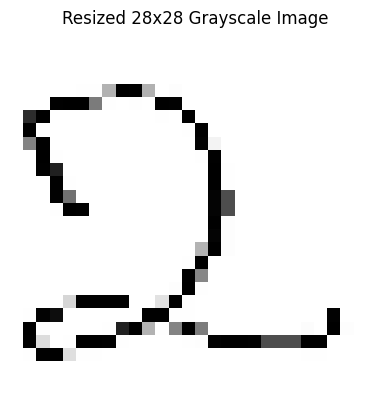

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Predicted Class:

[np.int64(5)]


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TRAIN MODEL
model.fit(
    X_train,
    y_train,
    epochs=1
)

import cv2
import matplotlib.pyplot as plt

from google.colab import files

#uploaded = files.upload()

image = cv2.imread("digit.png")

# Check if image was loaded correctly
if image is None:
    print("Error: Image not loaded. Check the file path.")
else:
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale Image")
    plt.axis("off")
    plt.show()

    # Resize the grayscale image to 28x28 (model input size)
    resized_28x28 = cv2.resize(gray, (28, 28))

    plt.imshow(resized_28x28, cmap='gray')
    plt.title("Resized 28x28 Grayscale Image")
    plt.axis("off")
    plt.show()

    # Normalize the image
    normalized_image = resized_28x28 / 255.0

    import numpy as np

    # Add a batch dimension, expected shape (1, 28, 28)
    input_image = np.expand_dims(normalized_image, axis=0)

    # Make prediction using the preprocessed input_image
    prediction = model.predict(input_image)

    predicted_label = prediction.argmax()

    print("Predicted Value:\n")
    print([predicted_label])
